<img src="logo-UNSAM.png" style="float: right;" width="300" alt="Logo">

# <center>Análisis y Procesamiento de Señales</center>
<hr>

## <center>**TS5**: "Estimación espectral - Ancho de banda de señales reales"</center>

<br><br>

### <center>1er Cuatrimestre - 2026</center>
### <center>**Alumno:** D'Alesio Alejo</center>


<br>

En esta práctica vamos a realizar la Estimación Espectral de Potencia (PSD) de señales reales. El enunciado nos pide utilizar un método visto en clase. Voy a utilizar el método de Welch.

Inicialmente visualizamos las señales a analizar.

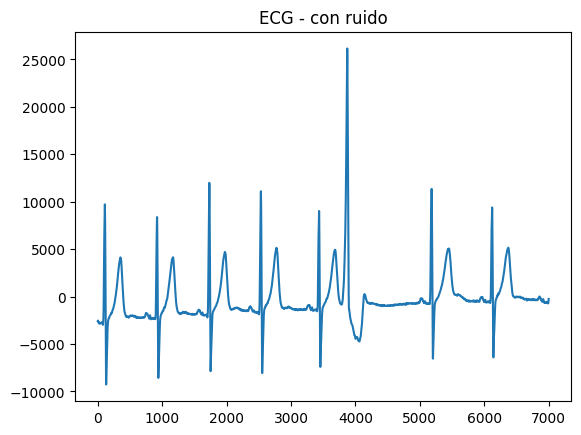

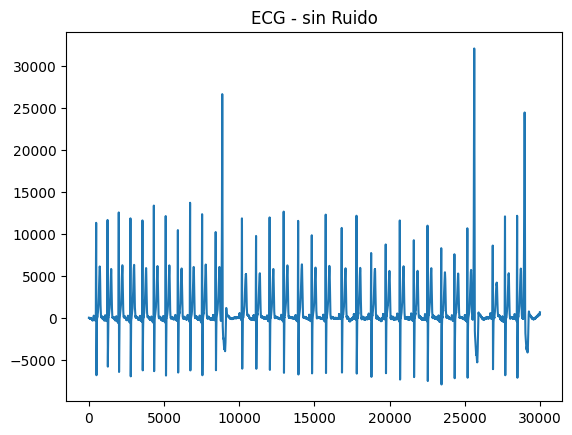

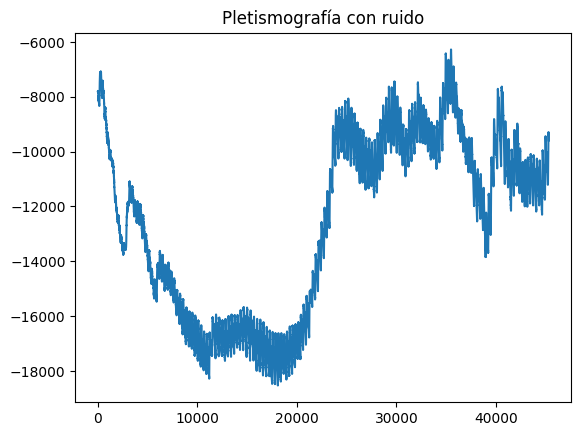

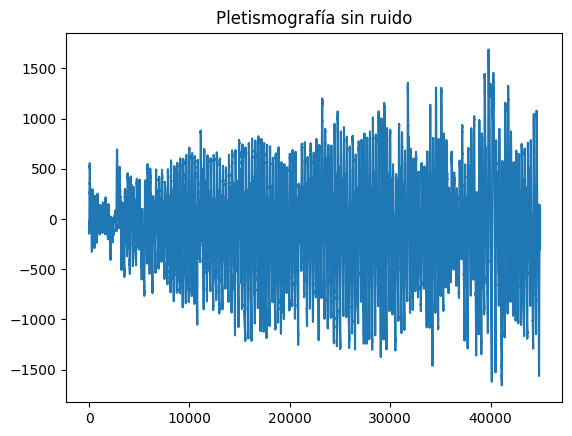

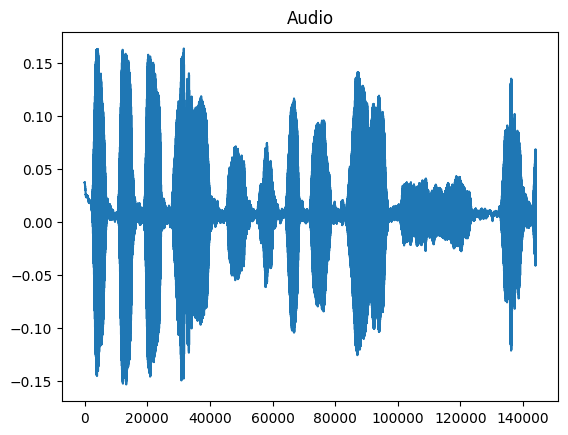

In [18]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write


##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz

##################
## ECG con ruido
##################

# para listar las variables que hay en el archivo
#io.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat(r'pdstestbench/ECG_TP4.mat')

ecg_one_lead_r = mat_struct['ecg_lead']
N = len(ecg_one_lead_r)

hb_1 = mat_struct['heartbeat_pattern1']
hb_2 = mat_struct['heartbeat_pattern2']

plt.figure()
plt.plot(ecg_one_lead_r[5000:12000])
plt.title('ECG - con ruido')

##################
## ECG sin ruido
##################

ecg_one_lead = np.load(r'pdstestbench/ecg_sin_ruido.npy')

plt.figure()
plt.plot(ecg_one_lead)
plt.title('ECG - sin Ruido')

####################################
# Lectura de pletismografía (PPG)  #
####################################

fs_ppg = 400 # Hz

##################
## PPG con ruido
##################

ppg_r = np.genfromtxt('pdstestbench/PPG.csv', delimiter=',', skip_header=1)

plt.figure()
plt.plot(ppg_r)
plt.title('Pletismografía con ruido')

##################
## PPG sin ruido
##################

ppg = np.load('pdstestbench/ppg_sin_ruido.npy')

plt.figure()
plt.plot(ppg)
plt.title('Pletismografía sin ruido')


#%%

####################
# Lectura de audio #
####################

fs_audio, wav_data = sio.wavfile.read('pdstestbench/la cucaracha.wav')


plt.figure()
plt.title('Audio')
plt.plot(wav_data)


Ahora aplico Welch a cada señal y grafico cada señal.

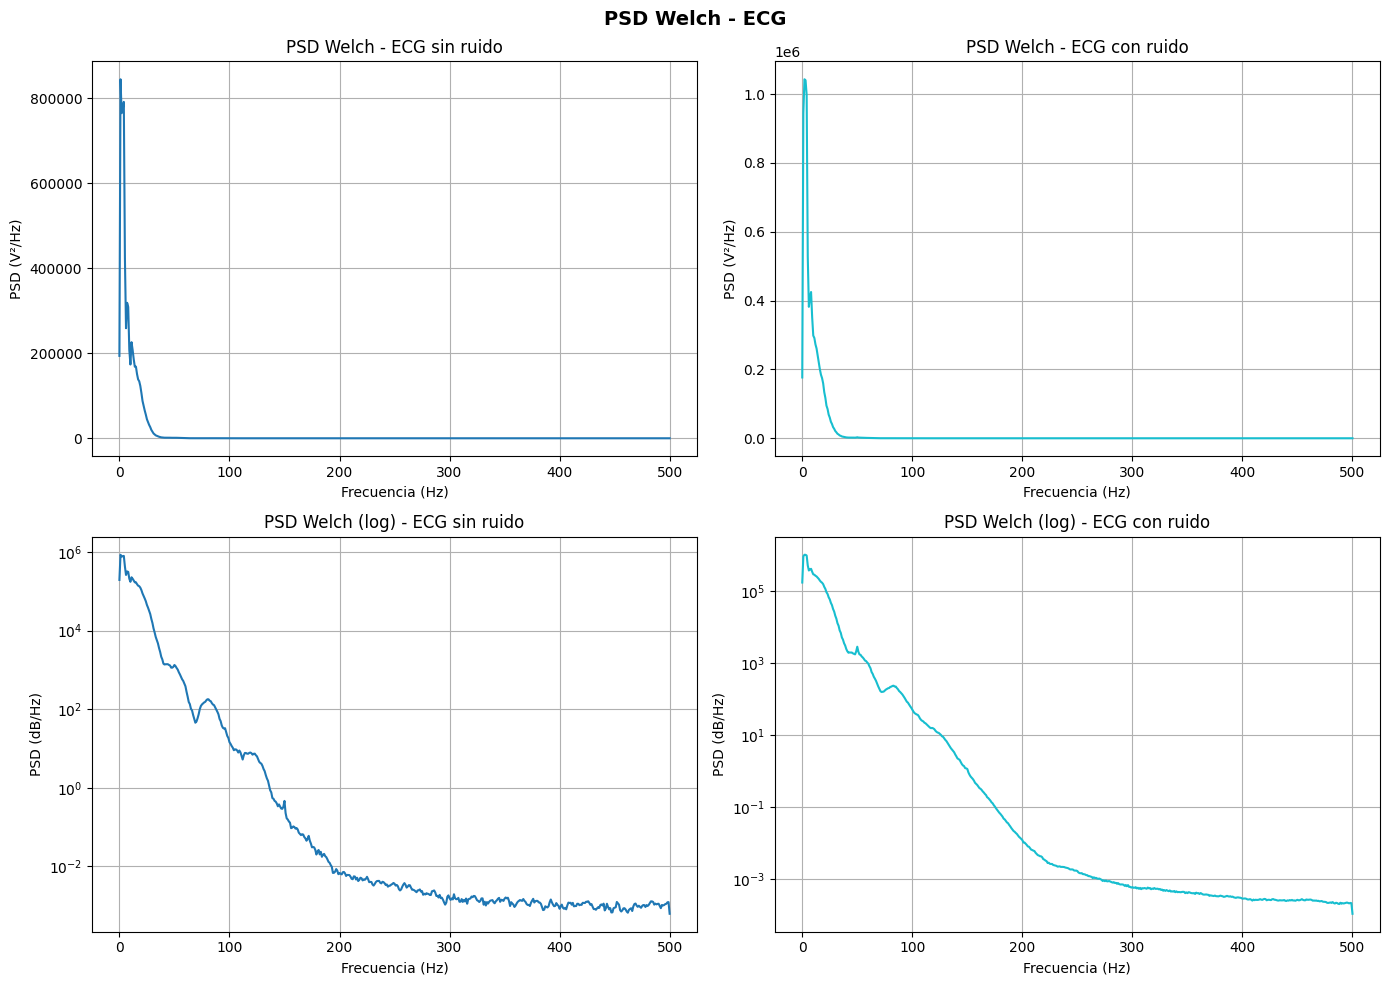

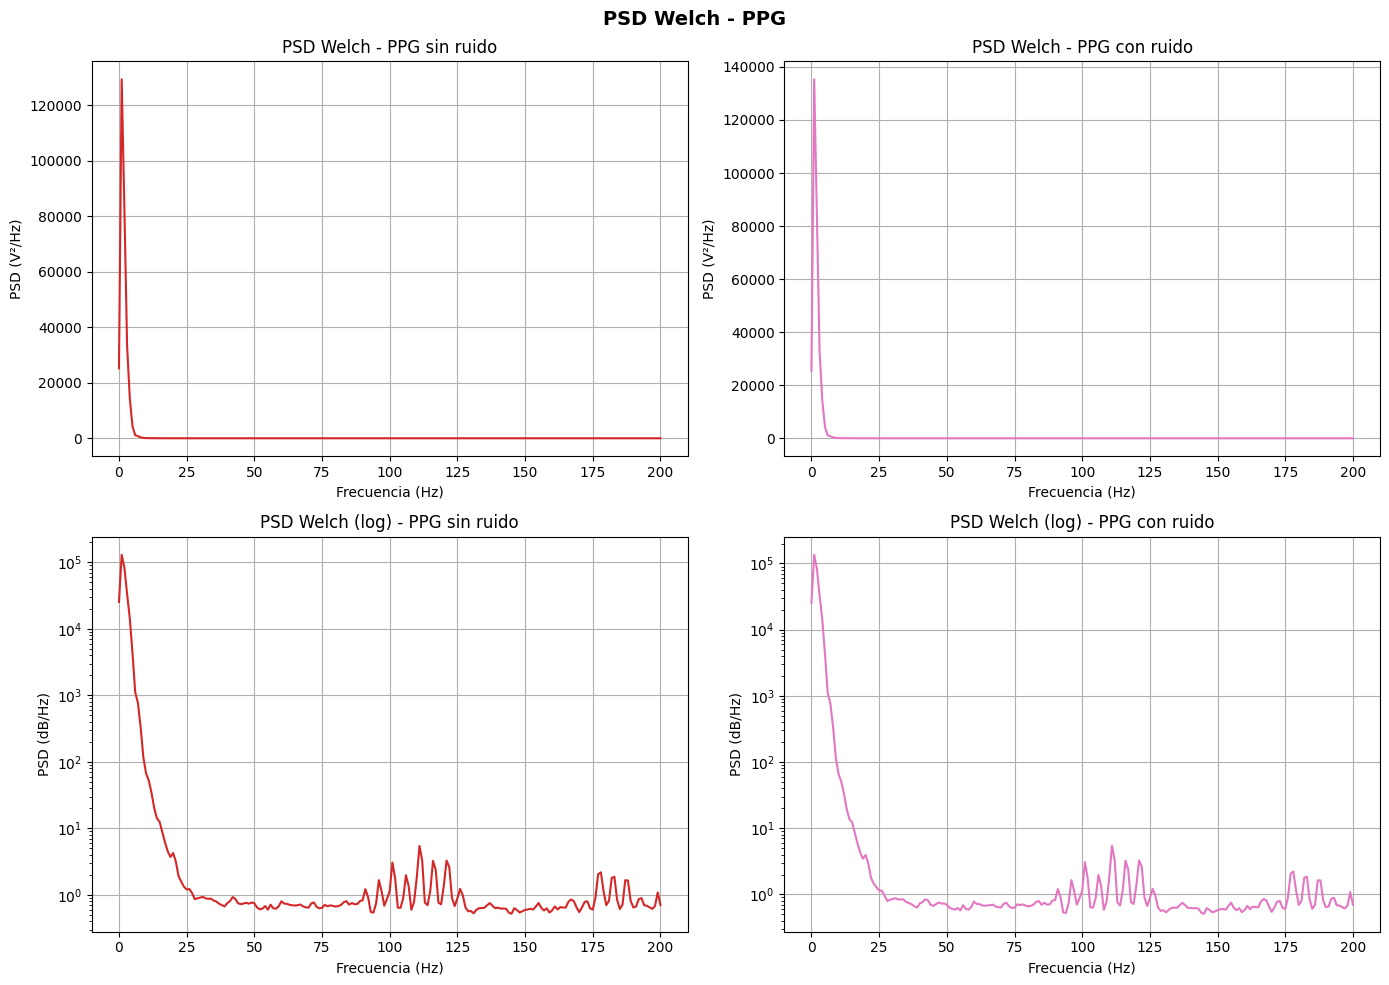

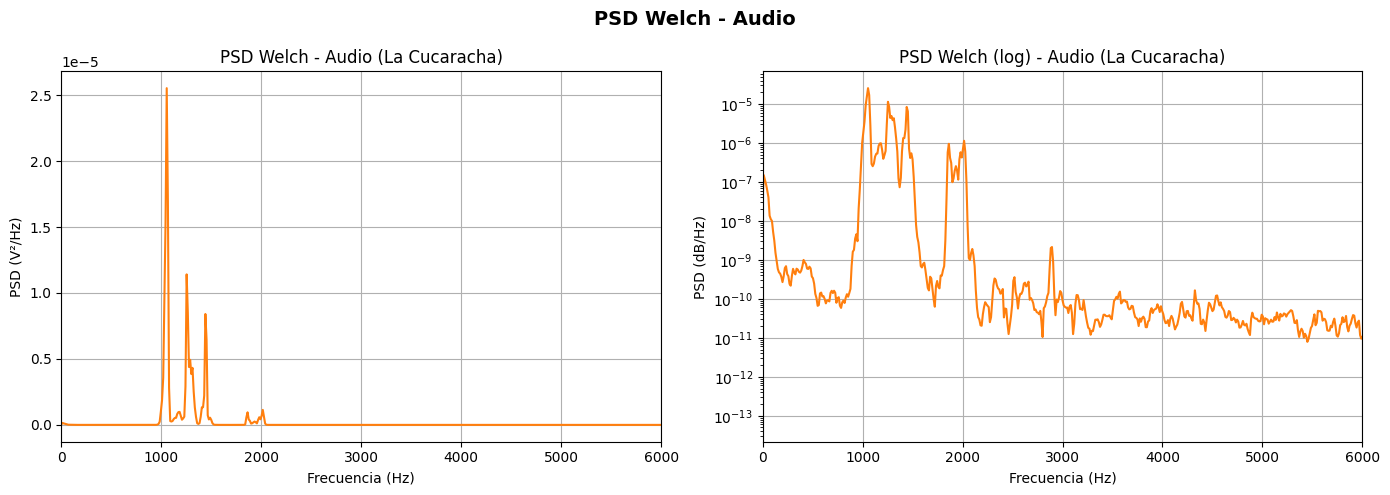

In [21]:
#%% ---- PSD --------
################
#----WELCH------
################
# 1) ECG 
#---- Sin Ruido--------
f_ECG, P_ECG = sig.welch(ecg_one_lead, fs_ecg, window='hann', nperseg=fs_ecg, noverlap=(fs_ecg/2), nfft=None, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
#---- Con Ruido ------
f_ECG_r, P_ECG_r = sig.welch(ecg_one_lead_r.flatten(), fs_ecg, window='hann', nperseg=fs_ecg, noverlap=(fs_ecg/2), nfft=None, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')

# 2) PPG
#---- Sin Ruido --------
f_PPG, P_PPG = sig.welch(ppg, fs_ppg, window='hann', nperseg=fs_ppg, noverlap=(fs_ppg/2), nfft=None, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
#---- Con Ruido --------
f_PPG_r, P_PPG_r = sig.welch(ppg_r.flatten(), fs_ppg, window='hann', nperseg=fs_ppg, noverlap=(fs_ppg/2), nfft=None, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')

# 3) Audio
if len(wav_data.shape) > 1:
    audio_procesar = wav_data[:, 0]
else:
    audio_procesar = wav_data

nperseg = 4096
noverlap = nperseg // 2
f_audio, P_audio = sig.welch(audio_procesar, fs_audio, window='hann', nperseg=nperseg, noverlap=noverlap)

#------GRAFICOS WELCH --------------
# =====================================================================
# --- FIGURA 1: ECG - Lineal y Logarítmica ---
# =====================================================================
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))

# Lineal - Sin ruido
axes1[0, 0].plot(f_ECG, P_ECG, color='tab:blue')
axes1[0, 0].set_title('PSD Welch - ECG sin ruido')
axes1[0, 0].set_xlabel('Frecuencia (Hz)')
axes1[0, 0].set_ylabel('PSD')
axes1[0, 0].grid(True)

# Lineal - Con ruido
axes1[0, 1].plot(f_ECG_r, P_ECG_r, color='tab:cyan')
axes1[0, 1].set_title('PSD Welch - ECG con ruido')
axes1[0, 1].set_xlabel('Frecuencia (Hz)')
axes1[0, 1].set_ylabel('PSD')
axes1[0, 1].grid(True)

# Logarítmica - Sin ruido
axes1[1, 0].semilogy(f_ECG, P_ECG, color='tab:blue')
axes1[1, 0].set_title('PSD Welch (log) - ECG sin ruido')
axes1[1, 0].set_xlabel('Frecuencia (Hz)')
axes1[1, 0].set_ylabel('PSD (dB)')
axes1[1, 0].grid(True)

# Logarítmica - Con ruido
axes1[1, 1].semilogy(f_ECG_r, P_ECG_r, color='tab:cyan')
axes1[1, 1].set_title('PSD Welch (log) - ECG con ruido')
axes1[1, 1].set_xlabel('Frecuencia (Hz)')
axes1[1, 1].set_ylabel('PSD (dB)')
axes1[1, 1].grid(True)

fig1.suptitle('PSD Welch - ECG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# --- FIGURA 2: PPG - Lineal y Logarítmica ---
# =====================================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))

# Lineal - Sin ruido
axes2[0, 0].plot(f_PPG, P_PPG, color='tab:red')
axes2[0, 0].set_title('PSD Welch - PPG sin ruido')
axes2[0, 0].set_xlabel('Frecuencia (Hz)')
axes2[0, 0].set_ylabel('PSD')
axes2[0, 0].grid(True)

# Lineal - Con ruido
axes2[0, 1].plot(f_PPG_r, P_PPG_r, color='tab:pink')
axes2[0, 1].set_title('PSD Welch - PPG con ruido')
axes2[0, 1].set_xlabel('Frecuencia (Hz)')
axes2[0, 1].set_ylabel('PSD')
axes2[0, 1].grid(True)

# Logarítmica - Sin ruido
axes2[1, 0].semilogy(f_PPG, P_PPG, color='tab:red')
axes2[1, 0].set_title('PSD Welch (log) - PPG sin ruido')
axes2[1, 0].set_xlabel('Frecuencia (Hz)')
axes2[1, 0].set_ylabel('PSD (dB)')
axes2[1, 0].grid(True)

# Logarítmica - Con ruido
axes2[1, 1].semilogy(f_PPG_r, P_PPG_r, color='tab:pink')
axes2[1, 1].set_title('PSD Welch (log) - PPG con ruido')
axes2[1, 1].set_xlabel('Frecuencia (Hz)')
axes2[1, 1].set_ylabel('PSD (dB)')
axes2[1, 1].grid(True)

fig2.suptitle('PSD Welch - PPG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# --- FIGURA 3: AUDIO - Lineal y Logarítmica ---
# =====================================================================
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

# Lineal
axes3[0].plot(f_audio, P_audio, color='tab:orange')
axes3[0].set_title('PSD Welch - Audio (La Cucaracha)')
axes3[0].set_xlabel('Frecuencia (Hz)')
axes3[0].set_ylabel('PSD')
axes3[0].set_xlim(0, 6000)
axes3[0].grid(True)

# Logarítmica
axes3[1].semilogy(f_audio, P_audio, color='tab:orange')
axes3[1].set_title('PSD Welch (log) - Audio (La Cucaracha)')
axes3[1].set_xlabel('Frecuencia (Hz)')
axes3[1].set_ylabel('PSD (dB)')
axes3[1].set_xlim(0, 6000)
axes3[1].grid(True)

fig3.suptitle('PSD Welch - Audio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Se observa que la estimación de PSD mediante el método de Welch permite identificar claramente el contenido frecuencial de cada señal. Tanto el ECG como el PPG concentran su energía en bajas frecuencias. En el caso del ECG, la señal con ruido presenta un piso espectral más elevado y una curva más suave, evidenciando la presencia de energía distribuida en todas las frecuencias producto del ruido. Para el PPG se observan además armónicos en frecuencias más altas. En el caso del audio, la energía se concentra en el rango de 1000-2000 Hz. La escala logarítmica resultó más adecuada para visualizar estas señales, ya que permite apreciar simultáneamente los picos de energía y el piso de ruido dado el amplio rango dinámico de las mismas.

Ahora vamos a realizar una estimación del ancho de banda de cada señal.